In [31]:
import numpy as np
import matplotlib.pyplot as plt

from ase.io import iread
import freud

In [36]:
path = r"D:\MS\md\TiO2\rutile_12\pos_md.xyz"

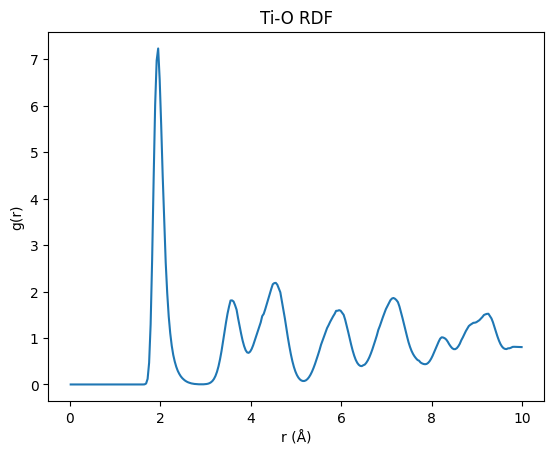

In [37]:
rdf = freud.density.RDF(
    bins=300,
    r_max=10
)

for frame in iread(path, format="lammps-dump-text"):

    cell = frame.cell.lengths()

    box = freud.box.Box(
        Lx=cell[0],
        Ly=cell[1],
        Lz=cell[2]
    )

    positions = frame.positions
    symbols = np.array(frame.get_chemical_symbols())

    ti_positions = positions[symbols == "Ti"]
    o_positions = positions[symbols == "O"]

    rdf.compute(
        system=(box, ti_positions),
        query_points=o_positions,
        reset=False
    )

plt.plot(rdf.bin_centers, rdf.rdf)

plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title("Ti-O RDF")

plt.show()